In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx

In [3]:
n1 = "\u0905\u0928\u093f\u0930\u0941\u0926\u094d\u0927 \u0936\u0930\u094d\u092e\u093e"   
n2 = "\u0935\u0948\u0936\u093e\u0932\u0940 \u0907\u0902\u0917\u0933\u0947 \u092e\u0948\u092e"
print(f"Submitted by {n1}\nChecked by {n2}")


Submitted by अनिरुद्ध शर्मा
Checked by वैशाली इंगळे मैम


In [4]:
data = pd.read_csv("Market_Basket_Optimisation.csv" , header=None)


In [5]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
transactions=data.shape[0]
print("no of transactions are :",transactions)

no of transactions are : 7501


In [7]:
transactions = []
for i in range(data.shape[0]):
    transaction = []
    for j in range(data.shape[1]):
        if  str(data.values[i, j]) != "nan":
            transaction.append(str(data.values[i, j]))
    transactions.append(transaction)

for i in range(5):
    print("Transaction", i+1, ":", transactions[i])


Transaction 1 : ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
Transaction 2 : ['burgers', 'meatballs', 'eggs']
Transaction 3 : ['chutney']
Transaction 4 : ['turkey', 'avocado']
Transaction 5 : ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']


In [8]:
te = TransactionEncoder()
x = te.fit_transform(transactions)

In [9]:
df = pd.DataFrame(x, columns = te.columns_)
df.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [10]:
freq_itemset = apriori(df, min_support = 0.03, use_colnames = True) 
freq_itemset.head()  

,support,itemsets
0,0.033329,(avocado)
1,0.033729,(brownies)
2,0.087188,(burgers)
3,0.030129,(butter)
4,0.081056,(cake)


In [11]:
rules = association_rules(freq_itemset,min_threshold = 0.2)
rules[['antecedents', 'consequents', 'support', 'confidence','lift']].head()

,antecedents,consequents,support,confidence,lift
0,(chocolate),(eggs),0.033196,0.202604,1.127397
1,(french fries),(chocolate),0.034395,0.201248,1.228284
2,(chocolate),(french fries),0.034395,0.209927,1.228284
3,(milk),(chocolate),0.032129,0.247942,1.513276
4,(mineral water),(chocolate),0.052660,0.220917,1.348332


Total number of rules generated: 27 

Rule: chocolate -> eggs Confidence: 0.203
Rule: french fries -> chocolate Confidence: 0.201
Rule: chocolate -> french fries Confidence: 0.210
Rule: milk -> chocolate Confidence: 0.248
Rule: mineral water -> chocolate Confidence: 0.221
Rule: chocolate -> mineral water Confidence: 0.321
Rule: spaghetti -> chocolate Confidence: 0.225
Rule: chocolate -> spaghetti Confidence: 0.239
Rule: french fries -> eggs Confidence: 0.213
Rule: eggs -> french fries Confidence: 0.203
Rule: milk -> eggs Confidence: 0.238
Rule: eggs -> mineral water Confidence: 0.283
Rule: mineral water -> eggs Confidence: 0.214
Rule: spaghetti -> eggs Confidence: 0.210
Rule: eggs -> spaghetti Confidence: 0.203
Rule: frozen vegetables -> mineral water Confidence: 0.375
Rule: green tea -> mineral water Confidence: 0.235
Rule: ground beef -> mineral water Confidence: 0.417
Rule: ground beef -> spaghetti Confidence: 0.399
Rule: spaghetti -> ground beef Confidence: 0.225
Rule: milk -> mine

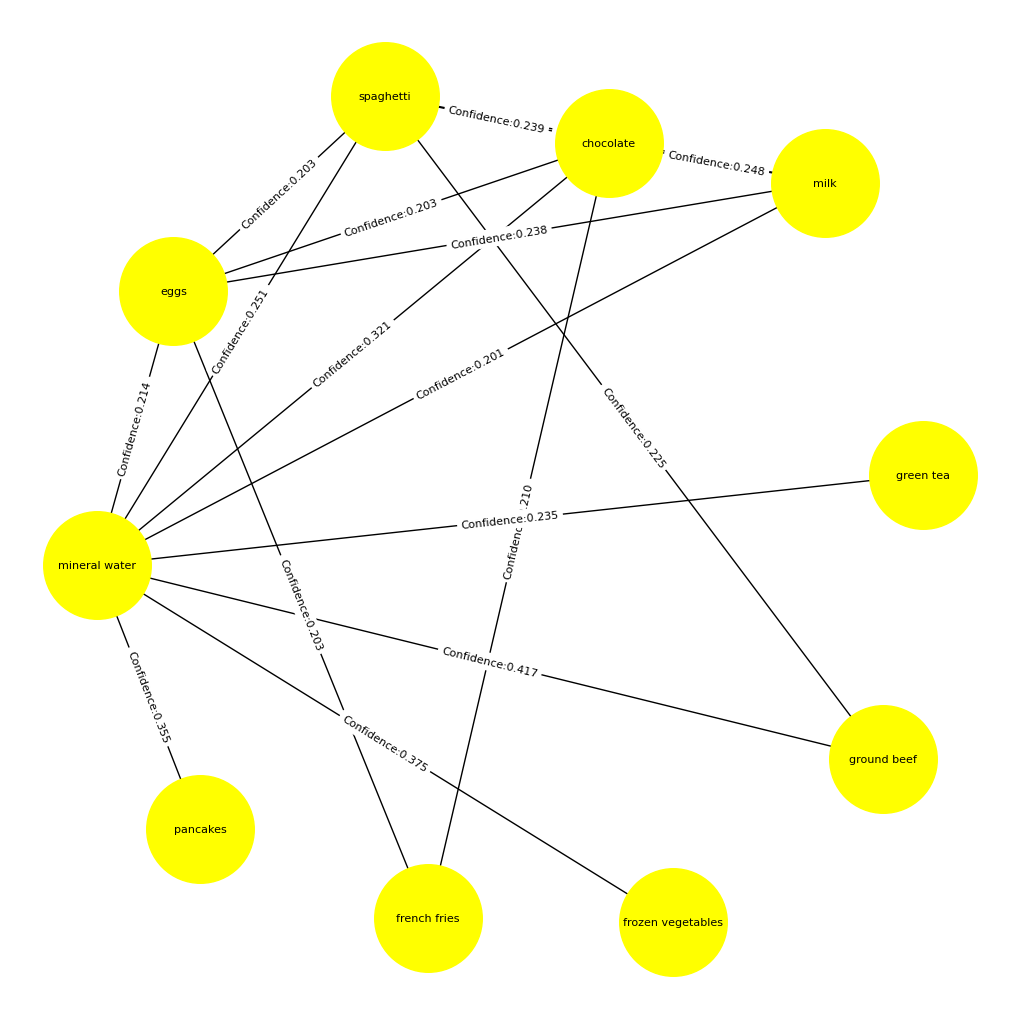

In [12]:
print("Total number of rules generated:" ,len(rules),"\n")

G = nx.Graph()

for _, rule in rules.iterrows():
    a = ", ".join(rule['antecedents'])
    c = ", ".join(rule['consequents'])
    conf = rule['confidence']
    print("Rule:",a, '->', c, 'Confidence:',f"{conf:.3f}")
    G.add_edge(a, c, label="Confidence:" + str(f"{conf:.3f}"))

# Prepare labels
pos = nx.spring_layout(G, k=15)
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_color='yellow', node_size=6000, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['label'] for u, v, d in G.edges(data=True)}, font_size=8)
plt.axis('off')
plt.show()